1. Операції з масивами даних у NumPy та Pandas

In [1]:
import numpy as np


array = np.array([1, 2, 3, 4, 5])

print(array.mean())

3.0


In [2]:
import pandas as pd


df = pd.DataFrame({
    'Name': ['Alice', 'Bob'],
    'Age': [24, 27]
})

print(df)

    Name  Age
0  Alice   24
1    Bob   27


2. Візуалізація даних за допомогою Matplotlib

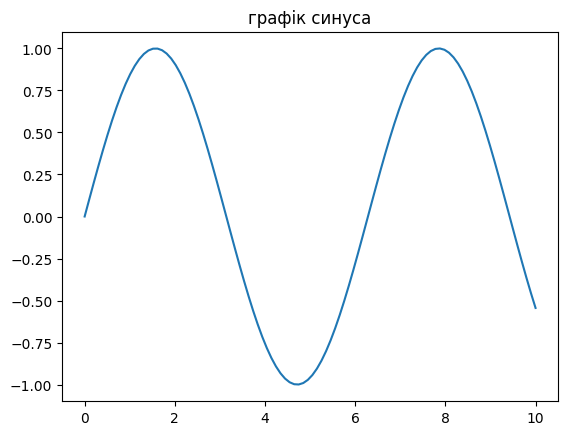

In [3]:
import matplotlib.pyplot as plt


x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title('графік синуса')
plt.show()

3. Створення та навчання простої нейронної мережі

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms


# Data laod
transform = transforms.Compose([transforms.ToTensor()])
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)

# Model definition
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Model learning
model = NeuralNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print('Навчання завершено!')

Навчання завершено!


4. Аналіз результатів

In [31]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        outputs = model(images)
        _, prediction = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (prediction == labels).sum().item()

accuracy = correct / total
print(f'Точність моделі {(accuracy * 100):.2f}%')

Точність моделі 98.92%


5. Тест на реальних даних

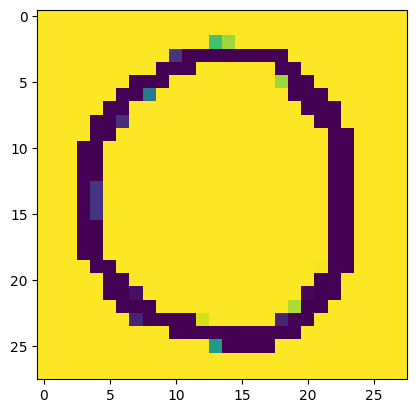

Передбачення: п'ять


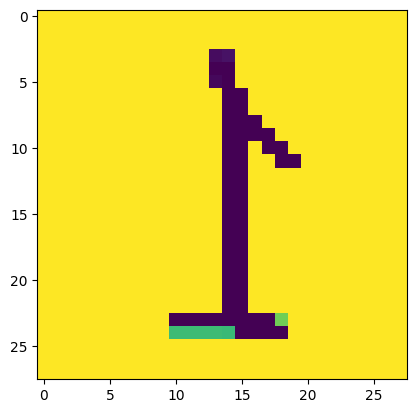

Передбачення: п'ять


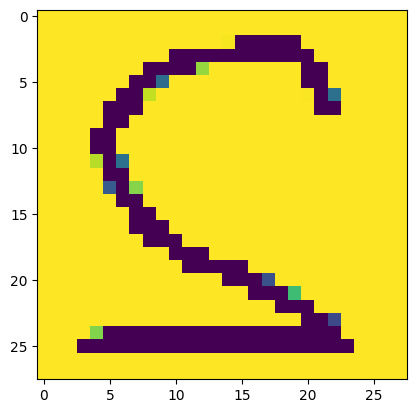

Передбачення: два


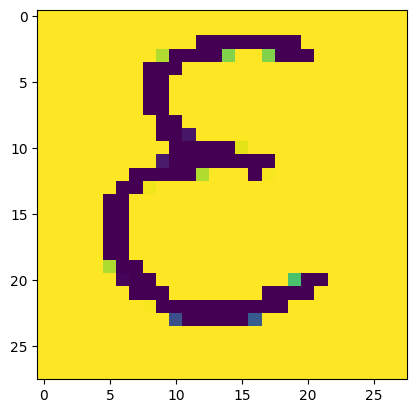

Передбачення: три


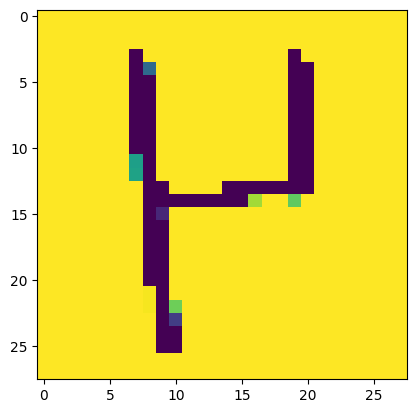

Передбачення: п'ять


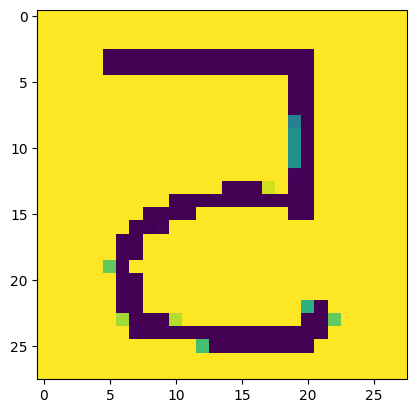

Передбачення: п'ять


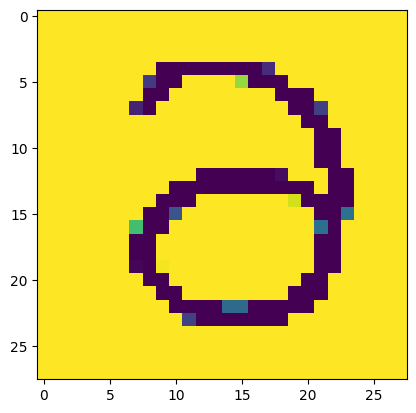

Передбачення: п'ять


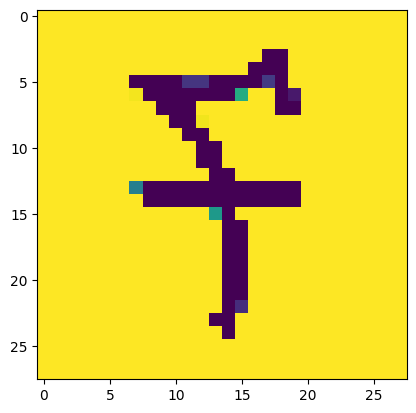

Передбачення: п'ять


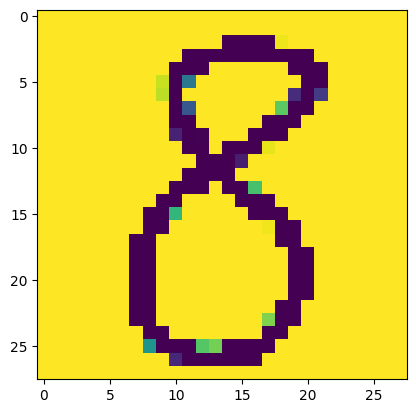

Передбачення: два


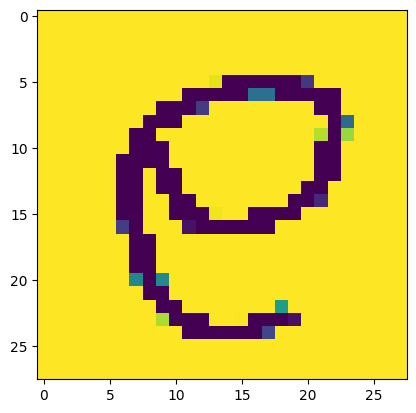

Передбачення: три


In [ ]:
import cv2

labels = ['нуль', 'один', 'два', 'три', 'чотри', 'п\'ять', 'шість', 'сім', 'вісім', 'дев\'ять']
directory = './testdata'
correct = 0
total = 0

for i in range(0, 10):
    img = cv2.imread(f'{directory}/{i}.png', cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28, 28))
    img = img.astype(np.float32) / 255.0
    img = cv2.flip(img, 1)
    
    img_tensor = torch.tensor(img).unsqueeze(0)
    img_tensor = img_tensor.view(-1, 28*28)
    
    plt.imshow(img)
    plt.show()

    outputs = model(img_tensor)
    _, prediction = torch.max(outputs.data, 1)
    
    print(f'Передбачення: {labels[prediction]}')

Контрольні питання

1. Які основні бібліотеки використовуються для роботи з генеративним ШІ?
    Для роботи з генеративним штучним інтелектом у Python використовуються бібліотеки для обробки тексту (Transformers, OpenAI API, LangChain), генерації зображень (Stable Diffusion, DALL·E, DeepDream) та музики (Magenta, Riffusion). TensorFlow і PyTorch є основними фреймворками для створення та тренування нейромереж. Також популярні спеціалізовані інструменти, як Diffusers для дифузійних моделей і SentenceTransformers для роботи з текстовими представленнями.
2. Яка роль NumPy та Pandas у підготовці даних?
    NumPy забезпечує ефективну роботу з багатовимірними масивами, математичними операціями та лінійною алгеброю, що важливо для обчислень і підготовки вхідних даних. Pandas використовується для обробки та аналізу табличних даних, включаючи очищення, фільтрацію, перетворення та агрегування, що полегшує підготовку даних для моделей машинного навчання.
3. Як Matplotlib допомагає аналізувати результати?
    Надаючи гнучкі інструменти для візуалізації даних у вигляді графіків і діаграм. Він дозволяє виявляти тенденції, аномалії та взаємозв’язки у даних через лінійні графіки, гістограми, розсіювання тощо.
4. Які кроки передбачає навчання нейронної мережі?
    Навчання нейронної мережі починається з підготовки даних, що включає очищення, нормалізацію та розбиття на вибірки. Далі йде створення моделі, де визначаються шари, нейрони та активаційні функції. Потім обирають функцію втрат і оптимізатор, після чого модель навчається на даних та оцінюється за допомогою тестової вибірки.
5. У чому різниця між PyTorch та TensorFlow?
    PyTorch має динамічну обчислювальну графіку, що робить його гнучкішим і зручнішим для досліджень та експериментів. TensorFlow використовує як статичну, так і динамічну графіку, що надає більше можливостей для розгортання моделей у продакшені.